In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [102]:
from google.colab import files

uploaded = files.upload()

Saving books_dataset CSV (COLLAB)_clean.csv to books_dataset CSV (COLLAB)_clean (8).csv


In [103]:
df = pd.read_csv("books_dataset CSV (COLLAB).csv")
df.head()

,Title,Price,Rating,Availability,Category,Product_URL
0,A Light in the Attic,Â£51.77,Three,In stock,Poetry,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,Historical Fiction,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,Fiction,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,Mystery,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,History,https://books.toscrape.com/catalogue/sapiens-a...


In [104]:
# Clean Price column
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("Â£", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [105]:
# Save clean data before Label Encoding
df.to_csv("books_dataset_clean.csv", index=False)

print("Clean CSV saved successfully!")

Clean CSV saved successfully!


In [106]:
from google.colab import files

files.download("books_dataset_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
from google.colab import files

files.download("books_dataset_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   object 
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   object 
 3   Availability  1000 non-null   object 
 4   Category      1000 non-null   object 
 5   Product_URL   1000 non-null   object 
dtypes: float64(1), object(5)
memory usage: 47.0+ KB


In [109]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1000, 6)


In [110]:
df.isnull().sum()

,0
Title,0
Price,0
Rating,0
Availability,0
Category,0
Product_URL,0


In [111]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [112]:
df["Price"].head(10)

,Price
0,51.77
1,53.74
2,50.10
3,47.82
4,54.23
5,22.65
6,33.34
7,17.93
8,22.60
9,52.15


In [113]:
df.describe()

,Price
count,1000.00000
mean,35.07035
std,14.44669
min,10.00000
25%,22.10750
50%,35.98000
75%,47.45750
max,59.99000


In [114]:
df["Rating"].value_counts()

,count
Rating,
One,226
Three,203
Five,196
Two,196
Four,179


In [115]:
df["Category"].value_counts()

,count
Category,
Default,152
Nonfiction,110
Sequential Art,75
Add a comment,67
Fiction,65
Young Adult,54
Fantasy,48
Romance,35
Mystery,32


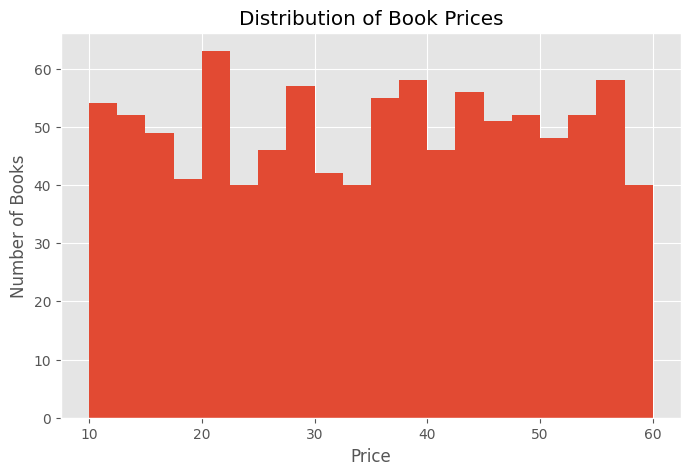

In [116]:
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=20)
plt.title("Distribution of Book Prices")
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.show()

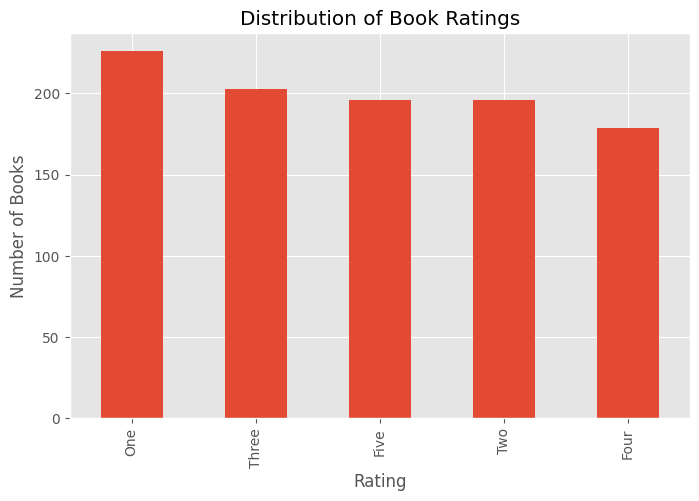

In [117]:
plt.figure(figsize=(8,5))
df["Rating"].value_counts().plot(kind="bar")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

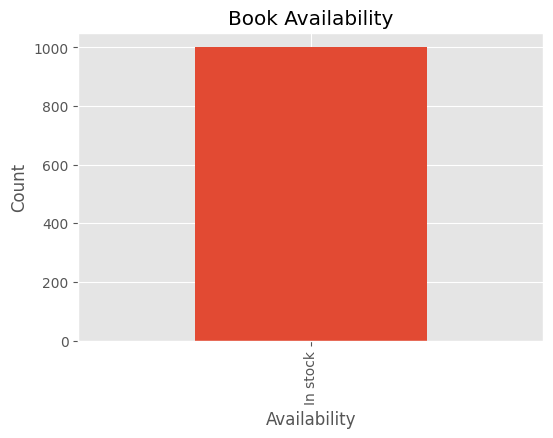

In [118]:
plt.figure(figsize=(6,4))
df["Availability"].value_counts().plot(kind="bar")

plt.title("Book Availability")
plt.xlabel("Availability")
plt.ylabel("Count")
plt.show()

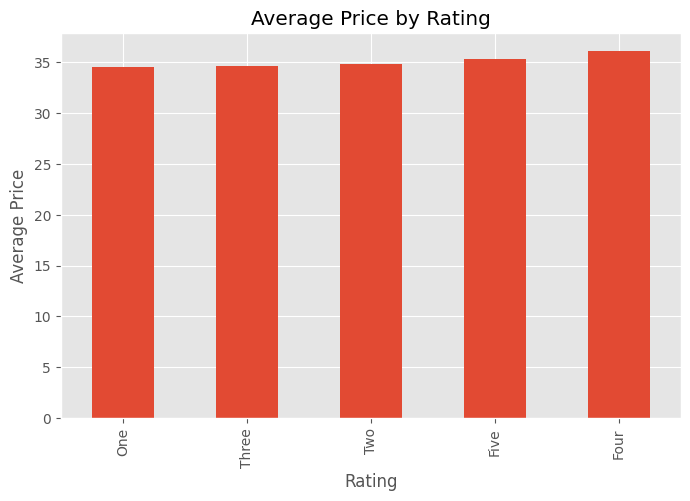

In [119]:
avg_price = df.groupby("Rating")["Price"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_price.plot(kind="bar")

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.show()

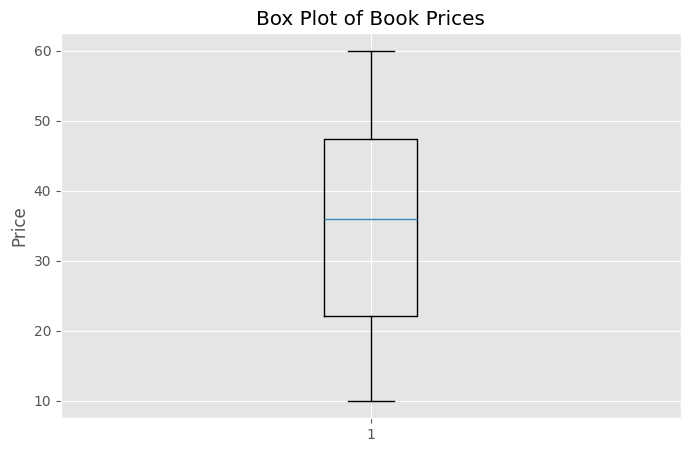

In [120]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Price"])

plt.title("Box Plot of Book Prices")
plt.ylabel("Price")
plt.show()

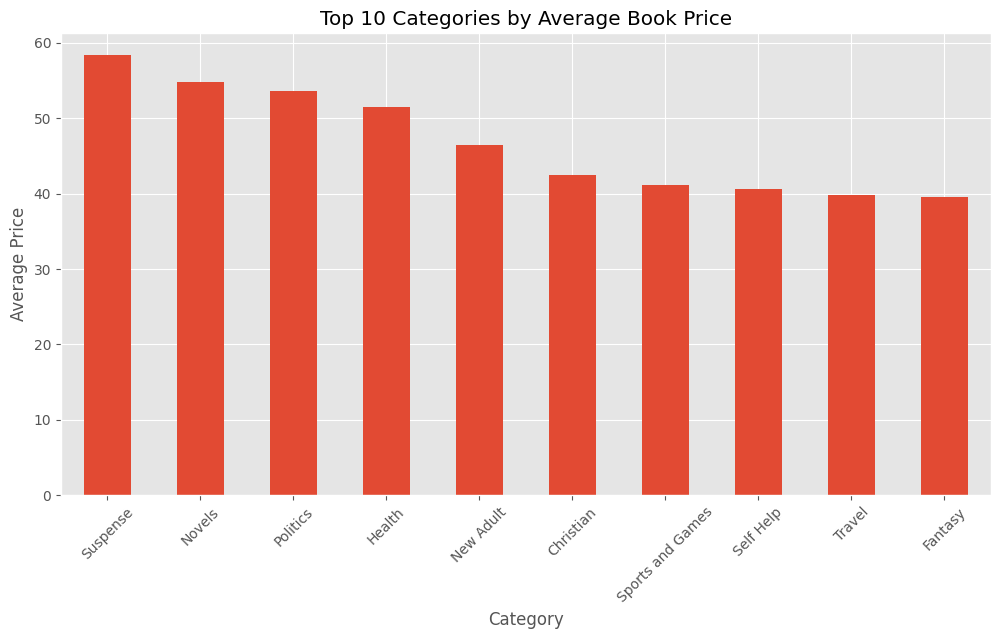

In [121]:
avg_price = df.groupby("Category")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
avg_price.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Average Book Price")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

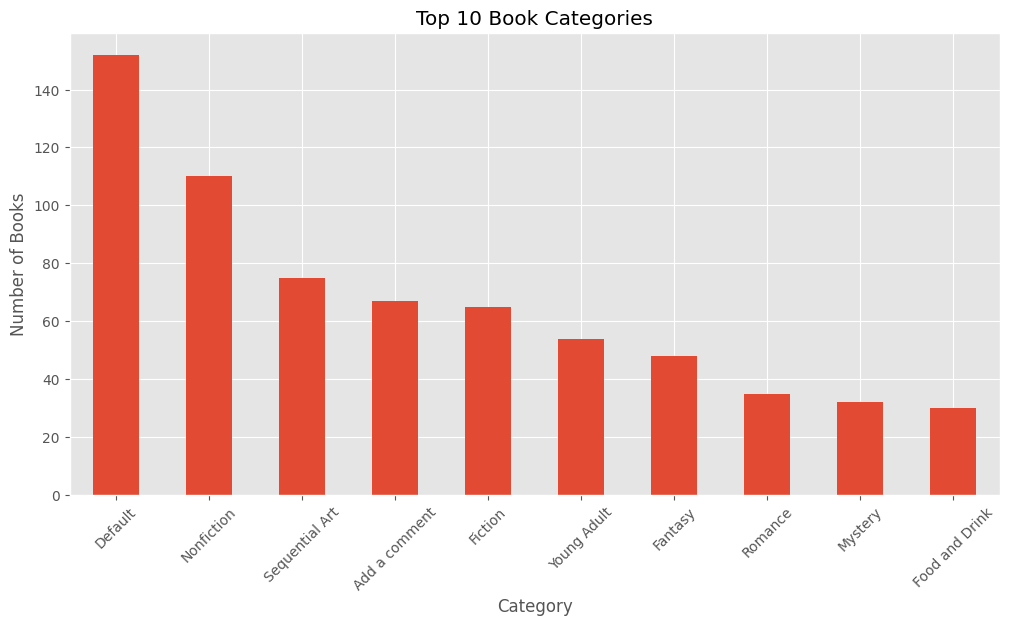

In [122]:
plt.figure(figsize=(12,6))
df["Category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Book Categories")
plt.xlabel("Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.show()

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [124]:
# Create LabelEncoder
le = LabelEncoder()

# Encode categorical columns
df["Category"] = le.fit_transform(df["Category"])
df["Availability"] = le.fit_transform(df["Availability"])
df["Rating"] = le.fit_transform(df["Rating"])

# Check the dataset
df.head()

,Title,Price,Rating,Availability,Category,Product_URL
0,A Light in the Attic,51.77,3,0,33,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,2,0,21,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,2,0,17,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,1,0,26,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,0,0,22,https://books.toscrape.com/catalogue/sapiens-a...


In [125]:
# Features
X = df[["Price", "Availability", "Category"]]

# Target
y = df["Rating"]

print(X.head())
print(y.head())

   Price  Availability  Category
0  51.77             0        33
1  53.74             0        21
2  50.10             0        17
3  47.82             0        26
4  54.23             0        22
0    3
1    2
2    2
3    1
4    0
Name: Rating, dtype: int64


In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 3)
Testing Data: (200, 3)


In [127]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [128]:
# Predict on test data
y_pred = model.predict(X_test)

print(y_pred[:10])

[4 0 1 0 4 1 3 0 4 2]


In [129]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.195


In [130]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.16      0.16      0.16        44
           1       0.21      0.17      0.19        36
           2       0.20      0.23      0.21        40
           3       0.26      0.26      0.26        42
           4       0.15      0.16      0.15        38

    accuracy                           0.20       200
   macro avg       0.20      0.19      0.19       200
weighted avg       0.20      0.20      0.19       200



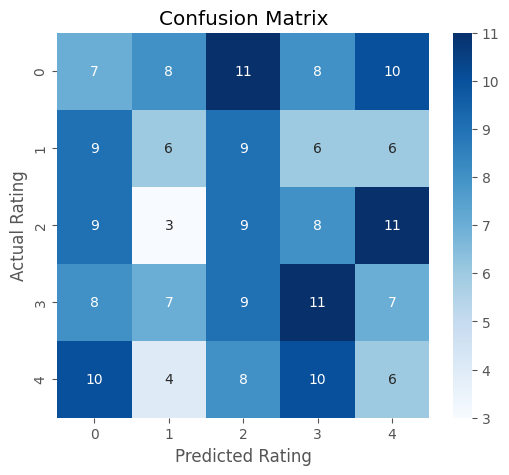

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.show()

In [132]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.195

Classification Report:

              precision    recall  f1-score   support

           0       0.16      0.16      0.16        44
           1       0.21      0.17      0.19        36
           2       0.20      0.23      0.21        40
           3       0.26      0.26      0.26        42
           4       0.15      0.16      0.15        38

    accuracy                           0.20       200
   macro avg       0.20      0.19      0.19       200
weighted avg       0.20      0.20      0.19       200



**Conclusion**

Successfully collected book data from the Books to Scrape website.

Performed data cleaning by converting the Price column into numeric format.

Conducted Exploratory Data Analysis (EDA) using summary statistics and visualizations.

Encoded categorical variables using LabelEncoder.

Split the dataset into training and testing sets.

Built a Random Forest Classification model to predict book ratings.

Evaluated the model using Accuracy Score, Classification Report, and Confusion Matrix.

The model achieved an accuracy of approximately 19.5%, indicating that the available features (Price, Category, and Availability) are not strong predictors of book ratings.

This project successfully demonstrates the complete machine learning workflow, including data collection, data preprocessing, exploratory data analysis, model building, and model evaluation using the Books to Scrape dataset.

